In [166]:
import h5py
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression, SGDRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
import time
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from pathlib import Path


In [167]:

# Configuration
TASK_MODE = 'sample'                  # 'parameter_set' uses Framework1 comparison; 'sample' uses Framework2 u0/coeff -> trajectory
FRAMEWORK_DIR_BY_TASK = {                    # maps each task mode to the framework folder that stores its PDE datasets
    'parameter_set': 'Framework1',
    'sample': 'Framework2',
}
BASE_DIR = Path(FRAMEWORK_DIR_BY_TASK[TASK_MODE])  # framework folder selected automatically from TASK_MODE
RESULTS_DIR = BASE_DIR                       # folder where result CSV files are written

PDE_NAME = 'Conservation_law'                # PDE folder to run; Framework1 uses Parametric_Wave, Framework2 uses Param_wave
DATA_SUBDIR = 'dataset_simple'               # subfolder inside the PDE folder that contains HDF5 files
DATA_FILENAME = 'solutions.h5'               # in-distribution HDF5 filename
OOD_FILENAME = 'ood.h5'                      # OOD HDF5 filename, used only if USE_OOD=True and the file exists
USE_OOD = True                               # if False, skip all OOD loading/evaluation/visualization

ICS_PER_PARAM = 20                           # number of initial conditions generated for each coefficient/parameter set; parameter_set mode only
TRAIN_FRACTION = 0.8                         # fraction of parameter sets/samples used for training
TRAIN_SIZE = 10000 if TASK_MODE == 'sample' else None  # Framework2 previously used 10000 samples; Framework1 uses TRAIN_FRACTION over parameter sets

PDE_DIR = BASE_DIR / PDE_NAME                # resolved PDE folder
DATA_PATH = PDE_DIR / DATA_SUBDIR / DATA_FILENAME  # in-distribution HDF5 path
OOD_PATH = PDE_DIR / DATA_SUBDIR / OOD_FILENAME    # OOD HDF5 path
DATA_KEY = 'data'                            # HDF5 dataset key for solution arrays, shape (N, T, X, C)
COEFF_KEY = 'coeffs'                         # HDF5 dataset key for PDE coefficient/parameter arrays
INPUT_TIME_INDEX = 0                         # time index used as the input initial condition u(t_index, x) in sample mode
CHANNEL_INDEX = 0                            # solution channel/variable index; 0 is the only valid choice if C=1

ALPHA = 1e-10                                # GPR nugget/noise regularization added to the kernel diagonal

VANILLA_RBF_LENGTH_SCALE = 100                                      # vanilla baseline on initial condition u0 -> trajectory
VANILLA_MATERN_LENGTH_SCALE = 1                                   # vanilla baseline on initial condition u0 -> trajectory
VANILLA_MATERN_NU = 5/2                                             # smoothness parameter for the vanilla Matern kernel

PRODUCT_COEF_LENGTH_SCALE = 1                # length scale for the coefficient Matern kernel in the product model; sample mode only
PRODUCT_COEF_NU = 5/2                        # smoothness parameter for the coefficient Matern kernel; sample mode only
PRODUCT_STATE_LENGTH_SCALE = 100             # length scale for the initial-condition Matern kernel in the product model; sample mode only
PRODUCT_STATE_NU = 3/2                       # smoothness parameter for the initial-condition Matern kernel; sample mode only

PRODUCT_RBF_COEF_LENGTH_SCALE = 1            # length scale for the coefficient RBF kernel in the product RBF model; sample mode only
PRODUCT_RBF_STATE_LENGTH_SCALE = 100         # length scale for the initial-condition RBF kernel in the product RBF model; sample mode only

FRAMEWORK1_RBF_LENGTH_SCALE = 10             # Framework1 method RBF length scale on coefficients W -> {G_W: U -> V}
FRAMEWORK1_MATERN_LENGTH_SCALE = 1            # Framework1 method Matern length scale on coefficients W -> {G_W: U -> V}
FRAMEWORK1_MATERN_NU = 5/2                    # Framework1 method Matern smoothness on coefficients

USE_PCA = False                              # master switch for PCA preprocessing
USE_X_PCA = True                             # if USE_PCA=True, reduce model inputs; in parameter_set mode these are coefficients
USE_COEF_PCA = True                          # if USE_PCA=True, reduce coefficient vectors for product kernels; sample mode only
USE_Y_PCA = True                             # if USE_PCA=True, reduce the output trajectory before learning
Y_PCA_BY_TIME = True                         # if True, fit one output PCA per time slice; in parameter_set mode each time slice contains all ICs and x-points

N_X_PCA = 5                                  # model-input PCA dimension
N_COEF_PCA = 4                               # coefficient PCA dimension for product kernels; sample mode only
N_Y_PCA = 5                                  # output PCA dimension; if Y_PCA_BY_TIME=True, this is per time slice

VIS_IDX = 0                                  # parameter-set/sample index used in the final visualization cell
VIS_IC_IDX = 0                               # initial-condition index to visualize when TASK_MODE='parameter_set'
VIS_PLOT_OOD = False                         # if True, visualize OOD predictions; otherwise visualize test predictions


In [168]:

# Load data and create train/test/OOD splits
if TASK_MODE not in FRAMEWORK_DIR_BY_TASK:
    raise ValueError(f'TASK_MODE must be one of {list(FRAMEWORK_DIR_BY_TASK)}.')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find {DATA_PATH}. Check TASK_MODE={TASK_MODE!r}, BASE_DIR={BASE_DIR}, and PDE_NAME={PDE_NAME!r}.'
    )
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with h5py.File(DATA_PATH, 'r') as f:
    dataset = f[DATA_KEY][:]
    coef = f[COEFF_KEY][:]

print('PDE:', PDE_NAME)
print('Task mode:', TASK_MODE)
print('Data path:', DATA_PATH)
print('Dataset shape:', dataset.shape)
print('Coefficient shape:', coef.shape)

if TASK_MODE == 'parameter_set':
    n_param_sets = dataset.shape[0] // ICS_PER_PARAM
    n_usable_samples = n_param_sets * ICS_PER_PARAM
    if n_usable_samples != dataset.shape[0]:
        print(f'Using first {n_usable_samples} samples so data is divisible by ICS_PER_PARAM={ICS_PER_PARAM}.')

    dataset_used = dataset[:n_usable_samples]
    coef_used = coef[:n_usable_samples]
    coef_by_param = coef_used[::ICS_PER_PARAM]
    Y_by_param = dataset_used[:, :, :, CHANNEL_INDEX].reshape(
        n_param_sets, ICS_PER_PARAM, dataset.shape[1], dataset.shape[2]
    )

    train_param_count = TRAIN_SIZE if TRAIN_SIZE is not None else int(TRAIN_FRACTION * n_param_sets)
    if train_param_count <= 0 or train_param_count >= n_param_sets:
        raise ValueError(f'train_param_count={train_param_count} must be between 1 and {n_param_sets - 1}.')
    train_sample_count = train_param_count * ICS_PER_PARAM

    # Vanilla baseline: initial condition -> trajectory, one row per IC trajectory.
    X_train = dataset_used[:train_sample_count, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_train = dataset_used[:train_sample_count, :, :, CHANNEL_INDEX]
    X_test = dataset_used[train_sample_count:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_test = dataset_used[train_sample_count:, :, :, CHANNEL_INDEX]
    coef_train = coef_used[:train_sample_count]
    coef_test = coef_used[train_sample_count:]

    # Framework1 method: coefficients -> all fixed-IC trajectories for that coefficient set.
    fw1_X_train = coef_by_param[:train_param_count]
    fw1_Y_train = Y_by_param[:train_param_count]
    fw1_X_test = coef_by_param[train_param_count:]
    fw1_Y_test = Y_by_param[train_param_count:]

elif TASK_MODE == 'sample':
    train_count = TRAIN_SIZE if TRAIN_SIZE is not None else int(TRAIN_FRACTION * dataset.shape[0])
    testSize = dataset.shape[0] - train_count
    if testSize <= 0:
        raise ValueError(f'train_count={train_count} leaves no test samples for dataset with {dataset.shape[0]} samples.')

    X_train = dataset[:train_count, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_train = dataset[:train_count, :, :, CHANNEL_INDEX]
    X_test = dataset[train_count:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_test = dataset[train_count:, :, :, CHANNEL_INDEX]
    coef_train = coef[:train_count]
    coef_test = coef[train_count:]

    fw1_X_train = fw1_Y_train = fw1_X_test = fw1_Y_test = None
else:
    raise ValueError("TASK_MODE must be either 'parameter_set' or 'sample'.")

HAS_OOD = bool(USE_OOD and Path(OOD_PATH).exists())
if HAS_OOD:
    with h5py.File(OOD_PATH, 'r') as f_ood:
        dataset_ood = f_ood[DATA_KEY][:]
        coef_ood_raw = f_ood[COEFF_KEY][:]

    if TASK_MODE == 'parameter_set':
        n_ood_param_sets = dataset_ood.shape[0] // ICS_PER_PARAM
        n_ood_usable_samples = n_ood_param_sets * ICS_PER_PARAM
        dataset_ood_used = dataset_ood[:n_ood_usable_samples]
        coef_ood_used = coef_ood_raw[:n_ood_usable_samples]
        fw1_X_ood = coef_ood_used[::ICS_PER_PARAM]
        fw1_Y_ood = dataset_ood_used[:, :, :, CHANNEL_INDEX].reshape(
            n_ood_param_sets, ICS_PER_PARAM, dataset_ood.shape[1], dataset_ood.shape[2]
        )

        X_ood = dataset_ood_used[:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
        Y_ood = dataset_ood_used[:, :, :, CHANNEL_INDEX]
        coef_ood = coef_ood_used
    else:
        X_ood = dataset_ood[:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
        Y_ood = dataset_ood[:, :, :, CHANNEL_INDEX]
        coef_ood = coef_ood_raw
        fw1_X_ood = fw1_Y_ood = None

    print('OOD path:', OOD_PATH)
else:
    dataset_ood = None
    coef_ood = None
    X_ood = None
    Y_ood = None
    fw1_X_ood = fw1_Y_ood = None
    if USE_OOD:
        print(f'OOD requested, but file not found: {OOD_PATH}. Skipping OOD evaluation.')
    else:
        print('OOD evaluation disabled.')

print('Vanilla train shapes:', X_train.shape, coef_train.shape, Y_train.shape)
print('Vanilla test shapes:', X_test.shape, coef_test.shape, Y_test.shape)
if TASK_MODE == 'parameter_set':
    print('Framework1 train shapes:', fw1_X_train.shape, fw1_Y_train.shape)
    print('Framework1 test shapes:', fw1_X_test.shape, fw1_Y_test.shape)
if HAS_OOD:
    print('Vanilla OOD shapes:', X_ood.shape, coef_ood.shape, Y_ood.shape)
    if TASK_MODE == 'parameter_set':
        print('Framework1 OOD shapes:', fw1_X_ood.shape, fw1_Y_ood.shape)


PDE: Conservation_law
Task mode: sample
Data path: Framework2/Conservation_law/dataset_simple/solutions.h5
Dataset shape: (14000, 64, 128, 1)
Coefficient shape: (14000, 4)
OOD path: Framework2/Conservation_law/dataset_simple/ood.h5
Vanilla train shapes: (10000, 128) (10000, 4) (10000, 64, 128)
Vanilla test shapes: (4000, 128) (4000, 4) (4000, 64, 128)
Vanilla OOD shapes: (4000, 128) (4000, 4) (4000, 64, 128)


In [169]:

# Optional PCA preprocessing
Y_TRAIN_SHAPE = Y_train.shape[1:]

Y_train_flat = Y_train.reshape(Y_train.shape[0], -1)
Y_test_flat = Y_test.reshape(Y_test.shape[0], -1)
Y_ood_flat = Y_ood.reshape(Y_ood.shape[0], -1) if HAS_OOD else None

# Vanilla/sample input PCA: u0 -> trajectory.
if USE_PCA and USE_X_PCA:
    n_x_components = min(N_X_PCA, X_train.shape[0], X_train.shape[1])
    x_pca = PCA(n_components=n_x_components)
    X_train_model = x_pca.fit_transform(X_train)
    X_test_model = x_pca.transform(X_test)
    X_ood_model = x_pca.transform(X_ood) if HAS_OOD else None
else:
    x_pca = None
    X_train_model = X_train
    X_test_model = X_test
    X_ood_model = X_ood if HAS_OOD else None

# Coefficient PCA for Framework2 product kernels only.
if USE_PCA and USE_COEF_PCA and TASK_MODE == 'sample':
    n_coef_components = min(N_COEF_PCA, coef_train.shape[0], coef_train.shape[1])
    coef_pca = PCA(n_components=n_coef_components)
    coef_train_model = coef_pca.fit_transform(coef_train)
    coef_test_model = coef_pca.transform(coef_test)
    coef_ood_model = coef_pca.transform(coef_ood) if HAS_OOD else None
else:
    coef_pca = None
    coef_train_model = coef_train
    coef_test_model = coef_test
    coef_ood_model = coef_ood if HAS_OOD else None

def outputs_by_time(Y):
    return np.moveaxis(Y, -2, 1)

def outputs_from_time(Y_by_time):
    return np.moveaxis(Y_by_time, 1, -2)

# Vanilla/sample output PCA: one PCA per time step on spatial functions.
if USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME:
    y_pcas = []
    y_component_slices = []
    y_train_parts = []
    Y_train_time = outputs_by_time(Y_train)
    per_time_shape = Y_train_time.shape[2:]
    start = 0
    for t in range(Y_train_time.shape[1]):
        Y_train_t = Y_train_time[:, t].reshape(Y_train.shape[0], -1)
        n_y_components = min(N_Y_PCA, Y_train_t.shape[0], Y_train_t.shape[1])
        pca_t = PCA(n_components=n_y_components)
        y_train_t = pca_t.fit_transform(Y_train_t)
        y_pcas.append(pca_t)
        y_train_parts.append(y_train_t)
        stop = start + n_y_components
        y_component_slices.append(slice(start, stop))
        start = stop
    Y_train_model = np.hstack(y_train_parts)

    def decode_prediction(prediction):
        prediction = np.asarray(prediction)
        decoded_times = []
        for pca_t, sl in zip(y_pcas, y_component_slices):
            decoded_t = pca_t.inverse_transform(prediction[:, sl]).reshape((prediction.shape[0],) + per_time_shape)
            decoded_times.append(decoded_t)
        return outputs_from_time(np.stack(decoded_times, axis=1))

    def decode_std(std):
        std = np.asarray(std)
        if std.ndim == 1:
            return std
        decoded_times = []
        for pca_t, sl in zip(y_pcas, y_component_slices):
            decoded_var_t = (std[:, sl]**2) @ (pca_t.components_**2)
            decoded_t = np.sqrt(np.maximum(decoded_var_t, 0.0)).reshape((std.shape[0],) + per_time_shape)
            decoded_times.append(decoded_t)
        return outputs_from_time(np.stack(decoded_times, axis=1))
elif USE_PCA and USE_Y_PCA:
    n_y_components = min(N_Y_PCA, Y_train_flat.shape[0], Y_train_flat.shape[1])
    y_pca = PCA(n_components=n_y_components)
    Y_train_model = y_pca.fit_transform(Y_train_flat)

    def decode_prediction(prediction):
        prediction = np.asarray(prediction)
        decoded = y_pca.inverse_transform(prediction)
        return decoded.reshape((-1,) + Y_TRAIN_SHAPE)

    def decode_std(std):
        std = np.asarray(std)
        if std.ndim == 1:
            return std
        decoded_var = (std**2) @ (y_pca.components_**2)
        return np.sqrt(np.maximum(decoded_var, 0.0)).reshape((-1,) + Y_TRAIN_SHAPE)
else:
    y_pca = None
    y_pcas = []
    Y_train_model = Y_train_flat

    def decode_prediction(prediction):
        return np.asarray(prediction).reshape((-1,) + Y_TRAIN_SHAPE)

    def decode_std(std):
        return std

# Framework1 method PCA: coefficients -> all fixed-IC trajectories.
# For output PCA by time, the same PCA basis is shared by every IC at that time step.
if TASK_MODE == 'parameter_set':
    if USE_PCA and USE_X_PCA:
        n_fw1_x_components = min(N_X_PCA, fw1_X_train.shape[0], fw1_X_train.shape[1])
        fw1_x_pca = PCA(n_components=n_fw1_x_components)
        fw1_X_train_model = fw1_x_pca.fit_transform(fw1_X_train)
        fw1_X_test_model = fw1_x_pca.transform(fw1_X_test)
        fw1_X_ood_model = fw1_x_pca.transform(fw1_X_ood) if HAS_OOD else None
    else:
        fw1_x_pca = None
        fw1_X_train_model = fw1_X_train
        fw1_X_test_model = fw1_X_test
        fw1_X_ood_model = fw1_X_ood if HAS_OOD else None

    fw1_Y_TRAIN_SHAPE = fw1_Y_train.shape[1:]
    fw1_Y_train_flat = fw1_Y_train.reshape(fw1_Y_train.shape[0], -1)

    if USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME:
        fw1_y_pcas = []
        fw1_y_component_slices = []
        fw1_y_train_parts = []
        fw1_n_ic = fw1_Y_train.shape[1]
        fw1_n_t = fw1_Y_train.shape[2]
        fw1_n_x = fw1_Y_train.shape[3]
        start = 0
        for t in range(fw1_n_t):
            # Shape is (n_params * n_ics, n_x): one shared spatial PCA for all ICs at this time.
            Y_t = fw1_Y_train[:, :, t, :].reshape(fw1_Y_train.shape[0] * fw1_n_ic, fw1_n_x)
            n_y_components = min(N_Y_PCA, Y_t.shape[0], Y_t.shape[1])
            pca_t = PCA(n_components=n_y_components)
            Y_t_model = pca_t.fit_transform(Y_t).reshape(fw1_Y_train.shape[0], fw1_n_ic * n_y_components)
            fw1_y_pcas.append(pca_t)
            fw1_y_train_parts.append(Y_t_model)
            stop = start + fw1_n_ic * n_y_components
            fw1_y_component_slices.append((slice(start, stop), n_y_components))
            start = stop
        fw1_Y_train_model = np.hstack(fw1_y_train_parts)

        def decode_fw1_prediction(prediction):
            prediction = np.asarray(prediction)
            decoded_times = []
            for pca_t, (sl, n_components) in zip(fw1_y_pcas, fw1_y_component_slices):
                coeffs_t = prediction[:, sl].reshape(prediction.shape[0] * fw1_n_ic, n_components)
                decoded_t = pca_t.inverse_transform(coeffs_t).reshape(prediction.shape[0], fw1_n_ic, fw1_n_x)
                decoded_times.append(decoded_t)
            return np.stack(decoded_times, axis=2)

        def decode_fw1_std(std):
            std = np.asarray(std)
            if std.ndim == 1:
                return std
            decoded_times = []
            for pca_t, (sl, n_components) in zip(fw1_y_pcas, fw1_y_component_slices):
                std_t = std[:, sl].reshape(std.shape[0] * fw1_n_ic, n_components)
                decoded_var_t = (std_t**2) @ (pca_t.components_**2)
                decoded_t = np.sqrt(np.maximum(decoded_var_t, 0.0)).reshape(std.shape[0], fw1_n_ic, fw1_n_x)
                decoded_times.append(decoded_t)
            return np.stack(decoded_times, axis=2)
    elif USE_PCA and USE_Y_PCA:
        n_fw1_y_components = min(N_Y_PCA, fw1_Y_train_flat.shape[0], fw1_Y_train_flat.shape[1])
        fw1_y_pca = PCA(n_components=n_fw1_y_components)
        fw1_Y_train_model = fw1_y_pca.fit_transform(fw1_Y_train_flat)

        def decode_fw1_prediction(prediction):
            prediction = np.asarray(prediction)
            return fw1_y_pca.inverse_transform(prediction).reshape((-1,) + fw1_Y_TRAIN_SHAPE)

        def decode_fw1_std(std):
            std = np.asarray(std)
            if std.ndim == 1:
                return std
            decoded_var = (std**2) @ (fw1_y_pca.components_**2)
            return np.sqrt(np.maximum(decoded_var, 0.0)).reshape((-1,) + fw1_Y_TRAIN_SHAPE)
    else:
        fw1_y_pca = None
        fw1_y_pcas = []
        fw1_Y_train_model = fw1_Y_train_flat

        def decode_fw1_prediction(prediction):
            return np.asarray(prediction).reshape((-1,) + fw1_Y_TRAIN_SHAPE)

        def decode_fw1_std(std):
            return std
else:
    fw1_x_pca = None
    fw1_X_train_model = fw1_X_test_model = fw1_X_ood_model = None
    fw1_Y_train_model = None

pca_tag = (
    f'pca_x{X_train_model.shape[1]}_c{coef_train_model.shape[1]}_y{Y_train_model.shape[1]}'
    if USE_PCA else 'no_pca'
)
if USE_PCA and TASK_MODE == 'parameter_set':
    pca_tag = f'{pca_tag}_fw1x{fw1_X_train_model.shape[1]}_fw1y{fw1_Y_train_model.shape[1]}'
pde_tag = str(PDE_NAME).replace('/', '_').replace(' ', '_')
task_tag = str(TASK_MODE).replace('/', '_').replace(' ', '_')
results_filename = f'results_{pde_tag}_{task_tag}_{pca_tag}.csv'
results_path = RESULTS_DIR / results_filename

print('PCA enabled:', USE_PCA)
print('X/input PCA enabled:', USE_PCA and USE_X_PCA)
print('Coefficient PCA enabled:', USE_PCA and USE_COEF_PCA and TASK_MODE == 'sample')
print('Y PCA enabled:', USE_PCA and USE_Y_PCA)
print('Y PCA by time:', USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME)
print('Vanilla X model shapes:', X_train_model.shape, X_test_model.shape, X_ood_model.shape if HAS_OOD else None)
print('Coefficient model shapes:', coef_train_model.shape, coef_test_model.shape, coef_ood_model.shape if HAS_OOD else None)
print('Vanilla Y train model shape:', Y_train_model.shape)
if TASK_MODE == 'parameter_set':
    print('Framework1 X model shapes:', fw1_X_train_model.shape, fw1_X_test_model.shape, fw1_X_ood_model.shape if HAS_OOD else None)
    print('Framework1 Y train model shape:', fw1_Y_train_model.shape)
print('Results file:', results_path)

if USE_PCA and USE_X_PCA:
    x_recon = x_pca.inverse_transform(X_train_model)
    x_recon_error = np.linalg.norm(x_recon - X_train) / np.linalg.norm(X_train)
    print('Vanilla X/input PCA explained variance:', np.sum(x_pca.explained_variance_ratio_))
    print('Vanilla X/input train reconstruction relative error:', x_recon_error)

if USE_PCA and USE_COEF_PCA and TASK_MODE == 'sample':
    coef_recon = coef_pca.inverse_transform(coef_train_model)
    coef_recon_error = np.linalg.norm(coef_recon - coef_train) / np.linalg.norm(coef_train)
    print('Coefficient PCA explained variance:', np.sum(coef_pca.explained_variance_ratio_))
    print('Coefficient train reconstruction relative error:', coef_recon_error)

if USE_PCA and USE_Y_PCA:
    y_recon = decode_prediction(Y_train_model)
    y_recon_error = np.linalg.norm(y_recon - Y_train) / np.linalg.norm(Y_train)
    if Y_PCA_BY_TIME:
        y_explained = np.mean([np.sum(pca_t.explained_variance_ratio_) for pca_t in y_pcas])
        print('Vanilla mean per-time Y PCA explained variance:', y_explained)
    else:
        print('Vanilla Y PCA explained variance:', np.sum(y_pca.explained_variance_ratio_))
    print('Vanilla Y train reconstruction relative error:', y_recon_error)

if USE_PCA and TASK_MODE == 'parameter_set':
    if USE_X_PCA:
        fw1_x_recon = fw1_x_pca.inverse_transform(fw1_X_train_model)
        fw1_x_recon_error = np.linalg.norm(fw1_x_recon - fw1_X_train) / np.linalg.norm(fw1_X_train)
        print('Framework1 X/coefficient PCA explained variance:', np.sum(fw1_x_pca.explained_variance_ratio_))
        print('Framework1 X/coefficient reconstruction relative error:', fw1_x_recon_error)
    if USE_Y_PCA:
        fw1_y_recon = decode_fw1_prediction(fw1_Y_train_model)
        fw1_y_recon_error = np.linalg.norm(fw1_y_recon - fw1_Y_train) / np.linalg.norm(fw1_Y_train)
        if Y_PCA_BY_TIME:
            fw1_y_explained = np.mean([np.sum(pca_t.explained_variance_ratio_) for pca_t in fw1_y_pcas])
            print('Framework1 mean per-time shared-IC Y PCA explained variance:', fw1_y_explained)
        else:
            print('Framework1 Y PCA explained variance:', np.sum(fw1_y_pca.explained_variance_ratio_))
        print('Framework1 Y train reconstruction relative error:', fw1_y_recon_error)


PCA enabled: False
X/input PCA enabled: False
Coefficient PCA enabled: False
Y PCA enabled: False
Y PCA by time: False
Vanilla X model shapes: (10000, 128) (4000, 128) (4000, 128)
Coefficient model shapes: (10000, 4) (4000, 4) (4000, 4)
Vanilla Y train model shape: (10000, 8192)
Results file: Framework2/results_Conservation_law_sample_no_pca.csv


# Vanilla Kernel

In [170]:

results = []


def relative_errors(pred, target):
    pred = np.asarray(pred)
    target = np.asarray(target)
    if TASK_MODE == 'parameter_set' and pred.ndim == 4:
        # Match the original Framework1 notebooks: report one error per IC trajectory,
        # even though the model predicts all ICs for a coefficient set together.
        pred = pred.reshape(-1, pred.shape[-2], pred.shape[-1])
        target = target.reshape(-1, target.shape[-2], target.shape[-1])
    error_axes = tuple(range(1, pred.ndim))
    numerator = np.sqrt(np.sum((pred - target)**2, axis=error_axes))
    denominator = np.sqrt(np.sum(target**2, axis=error_axes))
    return numerator / denominator


def sample_uncertainty(std):
    std = np.asarray(std)
    if std.ndim == 1:
        return std
    return np.sqrt(np.mean(std**2, axis=tuple(range(1, std.ndim))))


def add_result(method, kernel, split, errors, **params):
    row = {
        'pde': PDE_NAME,
        'task_mode': TASK_MODE,
        'method': method,
        'kernel': kernel,
        'split': split,
        'n_train': params.pop('n_train', X_train.shape[0]),
        'n_eval': params.pop('n_eval', len(errors)),
        'ics_per_param': ICS_PER_PARAM if TASK_MODE == 'parameter_set' else np.nan,
        'mean_relative_error': float(np.mean(errors)),
        'std_relative_error': float(np.std(errors)),
        'pca': USE_PCA,
        'x_model_dim': X_train_model.shape[1],
        'coef_model_dim': coef_train_model.shape[1],
        'y_model_dim': Y_train_model.shape[1],
        'fw1_x_model_dim': fw1_X_train_model.shape[1] if TASK_MODE == 'parameter_set' else np.nan,
        'fw1_y_model_dim': fw1_Y_train_model.shape[1] if TASK_MODE == 'parameter_set' else np.nan,
        'train_time_seconds': params.pop('train_time_seconds', np.nan),
        'predict_time_seconds': params.pop('predict_time_seconds', np.nan),
    }
    row.update(params)
    results.append(row)


def results_table():
    return pd.DataFrame(results)


def plot_uncertainty(name, test_uncertainty, test_error, ood_uncertainty=None):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(test_uncertainty, test_error, s=12, alpha=0.6)
    plt.xlabel('predictive std')
    plt.ylabel('relative error')
    plt.title(f'{name}: uncertainty vs error')

    plt.subplot(1, 2, 2)
    plt.hist(test_uncertainty, bins=30, alpha=0.6, label='test')
    if ood_uncertainty is not None:
        plt.hist(ood_uncertainty, bins=30, alpha=0.6, label='ood')
    plt.xlabel('predictive std')
    plt.ylabel('count')
    plt.title(f'{name}: uncertainty distribution')
    plt.legend()
    plt.tight_layout()


In [171]:
##################### RBF kernel
bandwidth = VANILLA_RBF_LENGTH_SCALE
kernel = RBF(length_scale=bandwidth)
model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_model, Y_train_model)
rbf_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
pred_flat, pred_std = model.predict(X_test_model, return_std=True)
rbf_test_predict_time = time.perf_counter() - start

pred = decode_prediction(pred_flat)
rbf_test_uncertainty = sample_uncertainty(decode_std(pred_std))
rbf_test_error = relative_errors(pred, Y_test)
e = np.mean(rbf_test_error)
add_result(
    'vanilla', 'RBF', 'test', rbf_test_error,
    length_scale=bandwidth, alpha=ALPHA,
    train_time_seconds=rbf_train_time,
    predict_time_seconds=rbf_test_predict_time,
)
print(f'RBF kernel: test error is {e:.2e}.')
print(f'RBF kernel: train time is {rbf_train_time:.2f}s, test predict time is {rbf_test_predict_time:.2f}s.\n')


RBF kernel: test error is 4.76e-02.
RBF kernel: train time is 14.64s, test predict time is 3.20s.



RBF kernel: out-of-distribution error is 7.50e-02.
RBF kernel: OOD predict time is 3.22s.



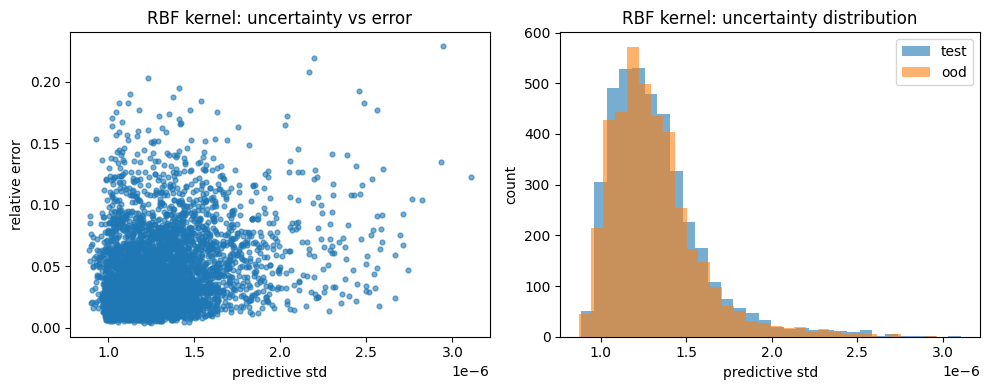

In [172]:
### out-of-distribution testing
if HAS_OOD:
    start = time.perf_counter()
    ood_pred_flat, ood_pred_std = model.predict(X_ood_model, return_std=True)
    rbf_ood_predict_time = time.perf_counter() - start

    ood_pred = decode_prediction(ood_pred_flat)
    rbf_ood_uncertainty = sample_uncertainty(decode_std(ood_pred_std))
    rbf_ood_error = relative_errors(ood_pred, Y_ood)
    ood_e = np.mean(rbf_ood_error)
    add_result(
        'vanilla', 'RBF', 'ood', rbf_ood_error,
        length_scale=bandwidth, alpha=ALPHA,
        train_time_seconds=rbf_train_time,
        predict_time_seconds=rbf_ood_predict_time,
    )
    print(f'RBF kernel: out-of-distribution error is {ood_e:.2e}.')
    print(f'RBF kernel: OOD predict time is {rbf_ood_predict_time:.2f}s.\n')
else:
    rbf_ood_uncertainty = None
    print('RBF kernel: OOD evaluation skipped.\n')

plot_uncertainty('RBF kernel', rbf_test_uncertainty, rbf_test_error, rbf_ood_uncertainty)


Matern kernel: test error is 6.67e-02.
Matern kernel: train time is 14.26s, test predict time is 3.29s.

Matern kernel: out-of-distribution error is 3.98e-02.
Matern kernel: OOD predict time is 3.46s.



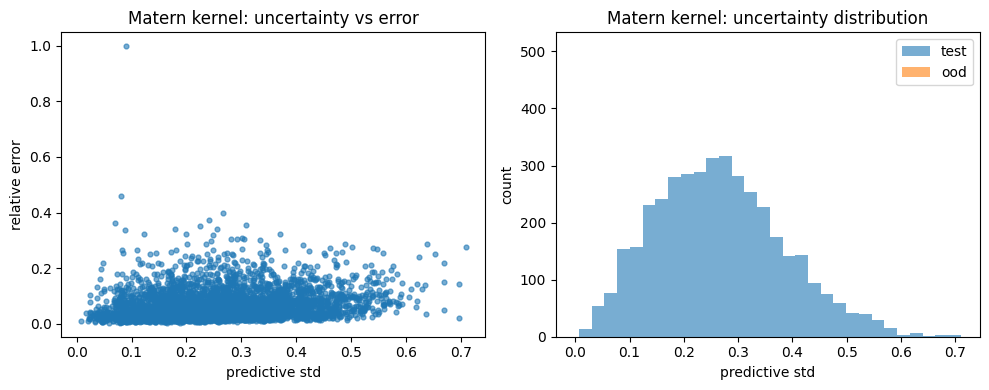

In [173]:
##################### Matern kernel
bandwidth = VANILLA_MATERN_LENGTH_SCALE
nu = VANILLA_MATERN_NU
kernel = Matern(length_scale=bandwidth, nu=nu)
model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_model, Y_train_model)
matern_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
matern_pred_flat, matern_pred_std = model.predict(X_test_model, return_std=True)
matern_test_predict_time = time.perf_counter() - start

matern_pred = decode_prediction(matern_pred_flat)
matern_test_uncertainty = sample_uncertainty(decode_std(matern_pred_std))
matern_test_error = relative_errors(matern_pred, Y_test)
matern_e = np.mean(matern_test_error)
add_result(
    'vanilla', 'Matern', 'test', matern_test_error,
    length_scale=bandwidth, nu=nu, alpha=ALPHA,
    train_time_seconds=matern_train_time,
    predict_time_seconds=matern_test_predict_time,
)
print(f'Matern kernel: test error is {matern_e:.2e}.')
print(f'Matern kernel: train time is {matern_train_time:.2f}s, test predict time is {matern_test_predict_time:.2f}s.\n')

### out-of-distribution testing
if HAS_OOD:
    start = time.perf_counter()
    matern_ood_pred_flat, matern_ood_pred_std = model.predict(X_ood_model, return_std=True)
    matern_ood_predict_time = time.perf_counter() - start

    matern_ood_pred = decode_prediction(matern_ood_pred_flat)
    matern_ood_uncertainty = sample_uncertainty(decode_std(matern_ood_pred_std))
    matern_ood_error = relative_errors(matern_ood_pred, Y_ood)
    matern_ood_e = np.mean(matern_ood_error)
    add_result(
        'vanilla', 'Matern', 'ood', matern_ood_error,
        length_scale=bandwidth, nu=nu, alpha=ALPHA,
        train_time_seconds=matern_train_time,
        predict_time_seconds=matern_ood_predict_time,
    )
    print(f'Matern kernel: out-of-distribution error is {matern_ood_e:.2e}.')
    print(f'Matern kernel: OOD predict time is {matern_ood_predict_time:.2f}s.\n')
else:
    matern_ood_uncertainty = None
    print('Matern kernel: OOD evaluation skipped.\n')

plot_uncertainty('Matern kernel', matern_test_uncertainty, matern_test_error, matern_ood_uncertainty)


In [174]:
results_df = results_table()
display(results_df)
results_df.to_csv(results_path, index=False)
print(f'Saved results to {results_path}')

results_df


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,x_model_dim,coef_model_dim,y_model_dim,fw1_x_model_dim,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu
0,Conservation_law,sample,vanilla,RBF,test,10000,4000,NaN,0.047571,0.032136,...,128,4,8192,NaN,NaN,14.637368,3.195180,100,1.000000e-10,NaN
1,Conservation_law,sample,vanilla,RBF,ood,10000,4000,NaN,0.074960,0.051710,...,128,4,8192,NaN,NaN,14.637368,3.224529,100,1.000000e-10,NaN
2,Conservation_law,sample,vanilla,Matern,test,10000,4000,NaN,0.066662,0.054495,...,128,4,8192,NaN,NaN,14.262927,3.285013,1,1.000000e-10,2.5
3,Conservation_law,sample,vanilla,Matern,ood,10000,4000,NaN,0.039798,0.032766,...,128,4,8192,NaN,NaN,14.262927,3.463401,1,1.000000e-10,2.5


Saved results to Framework2/results_Conservation_law_sample_no_pca.csv


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,x_model_dim,coef_model_dim,y_model_dim,fw1_x_model_dim,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu
0,Conservation_law,sample,vanilla,RBF,test,10000,4000,NaN,0.047571,0.032136,...,128,4,8192,NaN,NaN,14.637368,3.195180,100,1.000000e-10,NaN
1,Conservation_law,sample,vanilla,RBF,ood,10000,4000,NaN,0.074960,0.051710,...,128,4,8192,NaN,NaN,14.637368,3.224529,100,1.000000e-10,NaN
2,Conservation_law,sample,vanilla,Matern,test,10000,4000,NaN,0.066662,0.054495,...,128,4,8192,NaN,NaN,14.262927,3.285013,1,1.000000e-10,2.5
3,Conservation_law,sample,vanilla,Matern,ood,10000,4000,NaN,0.039798,0.032766,...,128,4,8192,NaN,NaN,14.262927,3.463401,1,1.000000e-10,2.5


# Our Method

Product GPR: test error is 1.76e-02.
Product GPR: train time is 15.56s, test predict time is 3.50s.

Product GPR: out-of-distribution error is 6.24e-02.
Product GPR: OOD predict time is 3.63s.



,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Conservation_law,sample,vanilla,RBF,test,10000,4000,NaN,0.047571,0.032136,...,NaN,14.637368,3.195180,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
1,Conservation_law,sample,vanilla,RBF,ood,10000,4000,NaN,0.074960,0.051710,...,NaN,14.637368,3.224529,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
2,Conservation_law,sample,vanilla,Matern,test,10000,4000,NaN,0.066662,0.054495,...,NaN,14.262927,3.285013,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN
3,Conservation_law,sample,vanilla,Matern,ood,10000,4000,NaN,0.039798,0.032766,...,NaN,14.262927,3.463401,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN
4,Conservation_law,sample,product_gpr,Matern x Matern,test,10000,4000,NaN,0.017589,0.015206,...,NaN,15.564980,3.500237,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
5,Conservation_law,sample,product_gpr,Matern x Matern,ood,10000,4000,NaN,0.062367,0.042425,...,NaN,15.564980,3.629142,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5


Saved results to Framework2/results_Conservation_law_sample_no_pca.csv


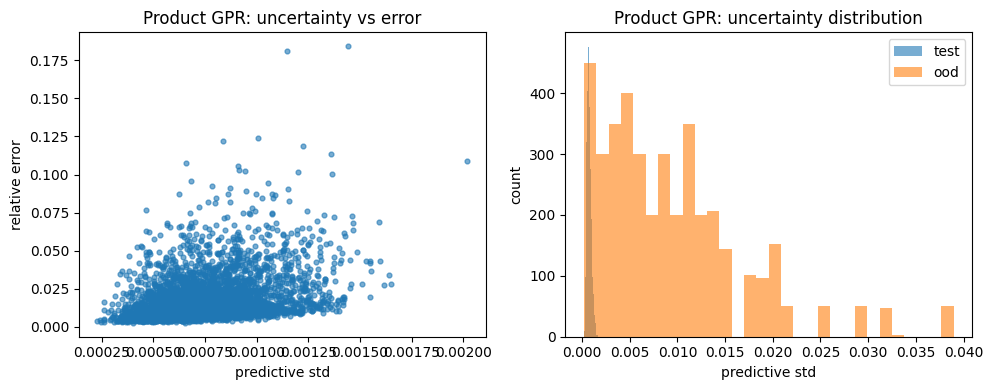

In [175]:

from sklearn.gaussian_process.kernels import Kernel


class ProductPDEKernel(Kernel):
    def __init__(self, n_u, coef_kernel=None, state_kernel=None):
        self.n_u = n_u
        self.coef_kernel = coef_kernel
        self.state_kernel = state_kernel

    def __call__(self, X, Y=None, eval_gradient=False):
        if eval_gradient:
            raise ValueError('Gradient is not implemented. Use optimizer=None.')

        X_u = X[:, :self.n_u]
        X_c = X[:, self.n_u:]

        if Y is None:
            Y_u = None
            Y_c = None
        else:
            Y_u = Y[:, :self.n_u]
            Y_c = Y[:, self.n_u:]

        return self.state_kernel(X_u, Y_u) * self.coef_kernel(X_c, Y_c)

    def diag(self, X):
        X_u = X[:, :self.n_u]
        X_c = X[:, self.n_u:]
        return self.state_kernel.diag(X_u) * self.coef_kernel.diag(X_c)

    def is_stationary(self):
        return self.state_kernel.is_stationary() and self.coef_kernel.is_stationary()


if TASK_MODE == 'parameter_set':
    ##################### Framework1 method: coefficients -> all fixed-IC trajectories, Matern kernel
    bandwidth = FRAMEWORK1_MATERN_LENGTH_SCALE
    nu = FRAMEWORK1_MATERN_NU
    kernel = Matern(length_scale=bandwidth, nu=nu)
    model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)
    start = time.perf_counter()
    model.fit(fw1_X_train_model, fw1_Y_train_model)
    product_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_pred_flat, product_pred_std = model.predict(fw1_X_test_model, return_std=True)
    product_test_predict_time = time.perf_counter() - start
    product_pred = decode_fw1_prediction(product_pred_flat)
    product_test_uncertainty = sample_uncertainty(decode_fw1_std(product_pred_std))
    product_test_error = relative_errors(product_pred, fw1_Y_test)
    product_e = np.mean(product_test_error)
    add_result(
        'framework1', 'Matern', 'test', product_test_error,
        length_scale=bandwidth, nu=nu, alpha=ALPHA,
        n_train=fw1_X_train.shape[0], n_eval=len(product_test_error),
        train_time_seconds=product_train_time,
        predict_time_seconds=product_test_predict_time,
    )
    print(f'Framework1 Matern: test error is {product_e:.2e}.')
    print(f'Framework1 Matern: train time is {product_train_time:.2f}s, test predict time is {product_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        start = time.perf_counter()
        product_ood_pred_flat, product_ood_pred_std = model.predict(fw1_X_ood_model, return_std=True)
        product_ood_predict_time = time.perf_counter() - start
        product_ood_pred = decode_fw1_prediction(product_ood_pred_flat)
        product_ood_uncertainty = sample_uncertainty(decode_fw1_std(product_ood_pred_std))
        product_ood_error = relative_errors(product_ood_pred, fw1_Y_ood)
        product_ood_e = np.mean(product_ood_error)
        add_result(
            'framework1', 'Matern', 'ood', product_ood_error,
            length_scale=bandwidth, nu=nu, alpha=ALPHA,
            n_train=fw1_X_train.shape[0], n_eval=len(product_ood_error),
            train_time_seconds=product_train_time,
            predict_time_seconds=product_ood_predict_time,
        )
        print(f'Framework1 Matern: out-of-distribution error is {product_ood_e:.2e}.')
        print(f'Framework1 Matern: OOD predict time is {product_ood_predict_time:.2f}s.\n')
    else:
        product_ood_pred = None
        product_ood_uncertainty = None
        print('Framework1 Matern: OOD evaluation skipped.\n')

    #plot_uncertainty('Framework1 Matern', product_test_uncertainty, product_test_error, product_ood_uncertainty)

else:
    ##################### Framework2 product Matern with GaussianProcessRegressor
    coef_bandwidth = PRODUCT_COEF_LENGTH_SCALE
    coef_nu = PRODUCT_COEF_NU
    state_bandwidth = PRODUCT_STATE_LENGTH_SCALE
    state_nu = PRODUCT_STATE_NU

    product_kernel = ProductPDEKernel(
        n_u=X_train_model.shape[1],
        coef_kernel=Matern(length_scale=coef_bandwidth, nu=coef_nu),
        state_kernel=Matern(length_scale=state_bandwidth, nu=state_nu),
    )

    X_train_product = np.hstack([X_train_model, coef_train_model])
    X_test_product = np.hstack([X_test_model, coef_test_model])
    X_ood_product = np.hstack([X_ood_model, coef_ood_model]) if HAS_OOD else None

    model = GaussianProcessRegressor(product_kernel, alpha=ALPHA, optimizer=None)

    start = time.perf_counter()
    model.fit(X_train_product, Y_train_model)
    product_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_pred_flat, product_pred_std = model.predict(X_test_product, return_std=True)
    product_test_predict_time = time.perf_counter() - start
    product_pred = decode_prediction(product_pred_flat)
    product_test_uncertainty = sample_uncertainty(decode_std(product_pred_std))
    product_test_error = relative_errors(product_pred, Y_test)
    product_e = np.mean(product_test_error)
    add_result(
        'product_gpr', 'Matern x Matern', 'test', product_test_error,
        coef_length_scale=coef_bandwidth, coef_nu=coef_nu,
        state_length_scale=state_bandwidth, state_nu=state_nu, alpha=ALPHA,
        train_time_seconds=product_train_time,
        predict_time_seconds=product_test_predict_time,
    )
    print(f'Product GPR: test error is {product_e:.2e}.')
    print(f'Product GPR: train time is {product_train_time:.2f}s, test predict time is {product_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        start = time.perf_counter()
        product_ood_pred_flat, product_ood_pred_std = model.predict(X_ood_product, return_std=True)
        product_ood_predict_time = time.perf_counter() - start
        product_ood_pred = decode_prediction(product_ood_pred_flat)
        product_ood_uncertainty = sample_uncertainty(decode_std(product_ood_pred_std))
        product_ood_error = relative_errors(product_ood_pred, Y_ood)
        product_ood_e = np.mean(product_ood_error)
        add_result(
            'product_gpr', 'Matern x Matern', 'ood', product_ood_error,
            coef_length_scale=coef_bandwidth, coef_nu=coef_nu,
            state_length_scale=state_bandwidth, state_nu=state_nu, alpha=ALPHA,
            train_time_seconds=product_train_time,
            predict_time_seconds=product_ood_predict_time,
        )
        print(f'Product GPR: out-of-distribution error is {product_ood_e:.2e}.')
        print(f'Product GPR: OOD predict time is {product_ood_predict_time:.2f}s.\n')
    else:
        product_ood_pred = None
        product_ood_uncertainty = None
        print('Product GPR: OOD evaluation skipped.\n')

    plot_uncertainty('Product GPR', product_test_uncertainty, product_test_error, product_ood_uncertainty)

results_df = results_table()
display(results_df)
results_df.to_csv(results_path, index=False)
print(f'Saved results to {results_path}')


Product RBF GPR: test error is 2.97e-02.
Product RBF GPR: train time is 14.93s, test predict time is 3.32s.

Product RBF GPR: out-of-distribution error is 9.36e-02.
Product RBF GPR: OOD predict time is 3.37s.



,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Conservation_law,sample,vanilla,RBF,test,10000,4000,NaN,0.047571,0.032136,...,NaN,14.637368,3.195180,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
1,Conservation_law,sample,vanilla,RBF,ood,10000,4000,NaN,0.074960,0.051710,...,NaN,14.637368,3.224529,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
2,Conservation_law,sample,vanilla,Matern,test,10000,4000,NaN,0.066662,0.054495,...,NaN,14.262927,3.285013,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN
3,Conservation_law,sample,vanilla,Matern,ood,10000,4000,NaN,0.039798,0.032766,...,NaN,14.262927,3.463401,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN
4,Conservation_law,sample,product_gpr,Matern x Matern,test,10000,4000,NaN,0.017589,0.015206,...,NaN,15.564980,3.500237,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
5,Conservation_law,sample,product_gpr,Matern x Matern,ood,10000,4000,NaN,0.062367,0.042425,...,NaN,15.564980,3.629142,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
6,Conservation_law,sample,product_gpr,RBF x RBF,test,10000,4000,NaN,0.029687,0.021464,...,NaN,14.933420,3.315525,NaN,1.000000e-10,NaN,1.0,NaN,100.0,NaN
7,Conservation_law,sample,product_gpr,RBF x RBF,ood,10000,4000,NaN,0.093622,0.064556,...,NaN,14.933420,3.369474,NaN,1.000000e-10,NaN,1.0,NaN,100.0,NaN


Saved results to Framework2/results_Conservation_law_sample_no_pca.csv


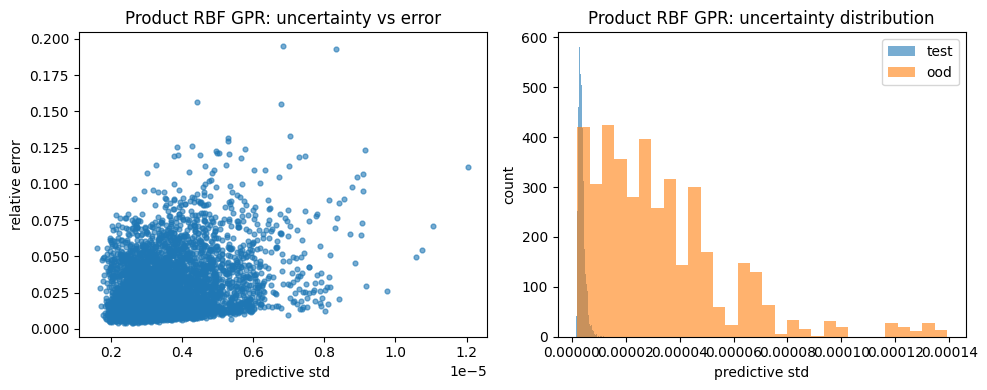

In [176]:

if TASK_MODE == 'parameter_set':
    ##################### Framework1 method: coefficients -> all fixed-IC trajectories, RBF kernel
    bandwidth = FRAMEWORK1_RBF_LENGTH_SCALE
    kernel = RBF(length_scale=bandwidth)
    model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)
    start = time.perf_counter()
    model.fit(fw1_X_train_model, fw1_Y_train_model)
    product_rbf_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_rbf_pred_flat, product_rbf_pred_std = model.predict(fw1_X_test_model, return_std=True)
    product_rbf_test_predict_time = time.perf_counter() - start
    product_rbf_pred = decode_fw1_prediction(product_rbf_pred_flat)
    product_rbf_test_uncertainty = sample_uncertainty(decode_fw1_std(product_rbf_pred_std))
    product_rbf_test_error = relative_errors(product_rbf_pred, fw1_Y_test)
    product_rbf_e = np.mean(product_rbf_test_error)
    add_result(
        'framework1', 'RBF', 'test', product_rbf_test_error,
        length_scale=bandwidth, alpha=ALPHA,
        n_train=fw1_X_train.shape[0], n_eval=len(product_rbf_test_error),
        train_time_seconds=product_rbf_train_time,
        predict_time_seconds=product_rbf_test_predict_time,
    )
    print(f'Framework1 RBF: test error is {product_rbf_e:.2e}.')
    print(f'Framework1 RBF: train time is {product_rbf_train_time:.2f}s, test predict time is {product_rbf_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        start = time.perf_counter()
        product_rbf_ood_pred_flat, product_rbf_ood_pred_std = model.predict(fw1_X_ood_model, return_std=True)
        product_rbf_ood_predict_time = time.perf_counter() - start
        product_rbf_ood_pred = decode_fw1_prediction(product_rbf_ood_pred_flat)
        product_rbf_ood_uncertainty = sample_uncertainty(decode_fw1_std(product_rbf_ood_pred_std))
        product_rbf_ood_error = relative_errors(product_rbf_ood_pred, fw1_Y_ood)
        product_rbf_ood_e = np.mean(product_rbf_ood_error)
        add_result(
            'framework1', 'RBF', 'ood', product_rbf_ood_error,
            length_scale=bandwidth, alpha=ALPHA,
            n_train=fw1_X_train.shape[0], n_eval=len(product_rbf_ood_error),
            train_time_seconds=product_rbf_train_time,
            predict_time_seconds=product_rbf_ood_predict_time,
        )
        print(f'Framework1 RBF: out-of-distribution error is {product_rbf_ood_e:.2e}.')
        print(f'Framework1 RBF: OOD predict time is {product_rbf_ood_predict_time:.2f}s.\n')
    else:
        product_rbf_ood_pred = None
        product_rbf_ood_uncertainty = None
        print('Framework1 RBF: OOD evaluation skipped.\n')

    #plot_uncertainty('Framework1 RBF', product_rbf_test_uncertainty, product_rbf_test_error, product_rbf_ood_uncertainty)

else:
    ##################### Product RBF with GaussianProcessRegressor
    coef_bandwidth = PRODUCT_RBF_COEF_LENGTH_SCALE
    state_bandwidth = PRODUCT_RBF_STATE_LENGTH_SCALE

    product_rbf_kernel = ProductPDEKernel(
        n_u=X_train_model.shape[1],
        coef_kernel=RBF(length_scale=coef_bandwidth),
        state_kernel=RBF(length_scale=state_bandwidth),
    )

    X_train_product = np.hstack([X_train_model, coef_train_model])
    X_test_product = np.hstack([X_test_model, coef_test_model])
    X_ood_product = np.hstack([X_ood_model, coef_ood_model]) if HAS_OOD else None

    model = GaussianProcessRegressor(product_rbf_kernel, alpha=ALPHA, optimizer=None)

    start = time.perf_counter()
    model.fit(X_train_product, Y_train_model)
    product_rbf_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_rbf_pred_flat, product_rbf_pred_std = model.predict(X_test_product, return_std=True)
    product_rbf_test_predict_time = time.perf_counter() - start
    product_rbf_pred = decode_prediction(product_rbf_pred_flat)
    product_rbf_test_uncertainty = sample_uncertainty(decode_std(product_rbf_pred_std))
    product_rbf_test_error = relative_errors(product_rbf_pred, Y_test)
    product_rbf_e = np.mean(product_rbf_test_error)
    add_result(
        'product_gpr', 'RBF x RBF', 'test', product_rbf_test_error,
        coef_length_scale=coef_bandwidth, state_length_scale=state_bandwidth, alpha=ALPHA,
        train_time_seconds=product_rbf_train_time,
        predict_time_seconds=product_rbf_test_predict_time,
    )
    print(f'Product RBF GPR: test error is {product_rbf_e:.2e}.')
    print(f'Product RBF GPR: train time is {product_rbf_train_time:.2f}s, test predict time is {product_rbf_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        start = time.perf_counter()
        product_rbf_ood_pred_flat, product_rbf_ood_pred_std = model.predict(X_ood_product, return_std=True)
        product_rbf_ood_predict_time = time.perf_counter() - start
        product_rbf_ood_pred = decode_prediction(product_rbf_ood_pred_flat)
        product_rbf_ood_uncertainty = sample_uncertainty(decode_std(product_rbf_ood_pred_std))
        product_rbf_ood_error = relative_errors(product_rbf_ood_pred, Y_ood)
        product_rbf_ood_e = np.mean(product_rbf_ood_error)
        add_result(
            'product_gpr', 'RBF x RBF', 'ood', product_rbf_ood_error,
            coef_length_scale=coef_bandwidth, state_length_scale=state_bandwidth, alpha=ALPHA,
            train_time_seconds=product_rbf_train_time,
            predict_time_seconds=product_rbf_ood_predict_time,
        )
        print(f'Product RBF GPR: out-of-distribution error is {product_rbf_ood_e:.2e}.')
        print(f'Product RBF GPR: OOD predict time is {product_rbf_ood_predict_time:.2f}s.\n')
    else:
        product_rbf_ood_pred = None
        product_rbf_ood_uncertainty = None
        print('Product RBF GPR: OOD evaluation skipped.\n')

    plot_uncertainty('Product RBF GPR', product_rbf_test_uncertainty, product_rbf_test_error, product_rbf_ood_uncertainty)

results_df = results_table()
display(results_df)
results_df.to_csv(results_path, index=False)
print(f'Saved results to {results_path}')


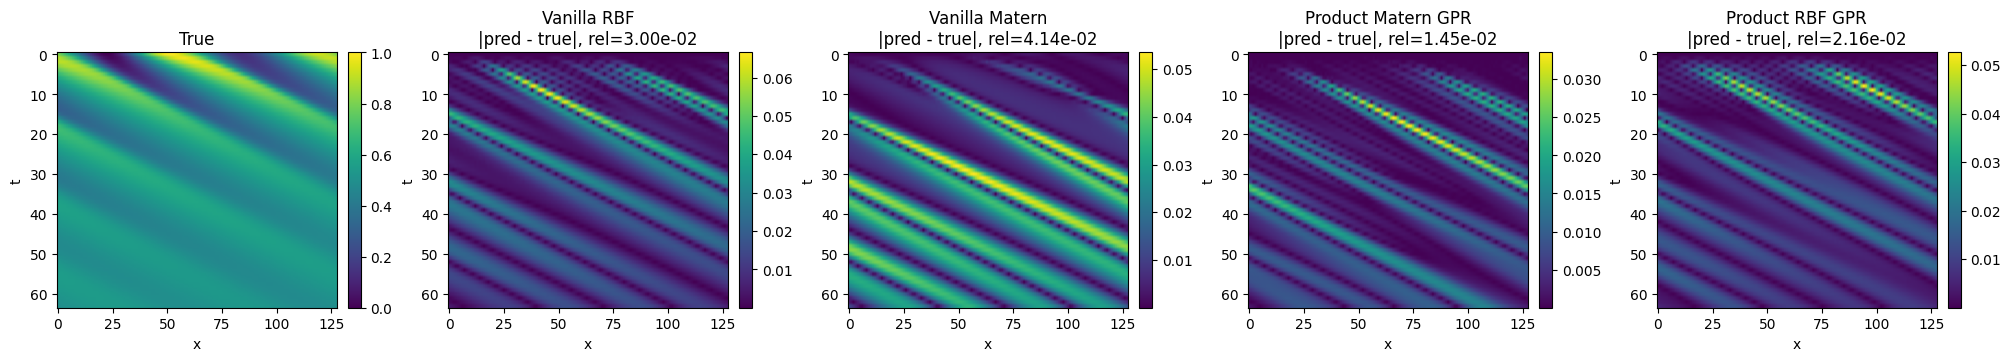

In [177]:

# visualization: true trajectory and prediction errors
idx = VIS_IDX
plot_ood = VIS_PLOT_OOD

if plot_ood and not HAS_OOD:
    raise ValueError('VIS_PLOT_OOD=True, but OOD evaluation is disabled or OOD file is unavailable.')

if TASK_MODE == 'parameter_set':
    param_idx = idx
    ic_idx = VIS_IC_IDX
    sample_idx = param_idx * ICS_PER_PARAM + ic_idx

    if plot_ood:
        target_plot = Y_ood[sample_idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('ood_pred'),
            'Vanilla Matern': globals().get('matern_ood_pred'),
            'Framework1 Matern': globals().get('product_ood_pred'),
            'Framework1 RBF': globals().get('product_rbf_ood_pred'),
        }
    else:
        target_plot = Y_test[sample_idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('pred'),
            'Vanilla Matern': globals().get('matern_pred'),
            'Framework1 Matern': globals().get('product_pred'),
            'Framework1 RBF': globals().get('product_rbf_pred'),
        }

    predictions_plot = {}
    for name, values in prediction_candidates.items():
        if values is None:
            continue
        if values.ndim == 4:
            predictions_plot[name] = values[param_idx, ic_idx]
        else:
            predictions_plot[name] = values[sample_idx]
    title_suffix = f'param {param_idx}, IC {ic_idx}'
else:
    if plot_ood:
        target_plot = Y_ood[idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('ood_pred'),
            'Vanilla Matern': globals().get('matern_ood_pred'),
            'Product Matern GPR': globals().get('product_ood_pred'),
            'Product RBF GPR': globals().get('product_rbf_ood_pred'),
        }
    else:
        target_plot = Y_test[idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('pred'),
            'Vanilla Matern': globals().get('matern_pred'),
            'Product Matern GPR': globals().get('product_pred'),
            'Product RBF GPR': globals().get('product_rbf_pred'),
        }

    predictions_plot = {
        name: values[idx]
        for name, values in prediction_candidates.items()
        if values is not None
    }
    title_suffix = ''

n_cols = len(predictions_plot) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

true_im = axes[0].imshow(target_plot, aspect='auto')
axes[0].set_title(f'True {title_suffix}'.strip())
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(true_im, ax=axes[0], fraction=0.046, pad=0.04)

for ax, (name, prediction_plot) in zip(axes[1:], predictions_plot.items()):
    error = np.abs(prediction_plot - target_plot)
    im = ax.imshow(error, aspect='auto')
    rel_error = np.linalg.norm(prediction_plot - target_plot) / np.linalg.norm(target_plot)
    ax.set_title(f'{name}\n|pred - true|, rel={rel_error:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()


In [178]:
import pandas as pd
from IPython.display import display

def load_results_csv(path):
    df = pd.read_csv(path)
    display(df)
    return df

df = load_results_csv(results_path)


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Conservation_law,sample,vanilla,RBF,test,10000,4000,NaN,0.047571,0.032136,...,NaN,14.637368,3.195180,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
1,Conservation_law,sample,vanilla,RBF,ood,10000,4000,NaN,0.074960,0.051710,...,NaN,14.637368,3.224529,100.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN
2,Conservation_law,sample,vanilla,Matern,test,10000,4000,NaN,0.066662,0.054495,...,NaN,14.262927,3.285013,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN
3,Conservation_law,sample,vanilla,Matern,ood,10000,4000,NaN,0.039798,0.032766,...,NaN,14.262927,3.463401,1.0,1.000000e-10,2.5,NaN,NaN,NaN,NaN
4,Conservation_law,sample,product_gpr,Matern x Matern,test,10000,4000,NaN,0.017589,0.015206,...,NaN,15.564980,3.500237,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
5,Conservation_law,sample,product_gpr,Matern x Matern,ood,10000,4000,NaN,0.062367,0.042425,...,NaN,15.564980,3.629142,NaN,1.000000e-10,NaN,1.0,2.5,100.0,1.5
6,Conservation_law,sample,product_gpr,RBF x RBF,test,10000,4000,NaN,0.029687,0.021464,...,NaN,14.933420,3.315525,NaN,1.000000e-10,NaN,1.0,NaN,100.0,NaN
7,Conservation_law,sample,product_gpr,RBF x RBF,ood,10000,4000,NaN,0.093622,0.064556,...,NaN,14.933420,3.369474,NaN,1.000000e-10,NaN,1.0,NaN,100.0,NaN
